## PyFolio

#### Способы загрузки данных
* файл
* pandas_datareader.web.get_data_yahoo
* Yahoo через quantstats

#### Формат данных

Oдна колонка, pandas.Series, индекс pandas.Timestamp UTC.
```
                              Close
Date
2012-05-21 00:00:00+00:00 -0.109861
2012-05-22 00:00:00+00:00 -0.089039
2012-05-23 00:00:00+00:00  0.032258
2012-05-24 00:00:00+00:00  0.032187
```
В данных лежит Float rel return (в процентах) за интервал.

Start date,2021-01-20
End date,2021-06-21
Total months,123
,Backtest
Annual return,0.145%
Cumulative returns,1.502%
Annual volatility,0.798%
Sharpe ratio,0.19
Calmar ratio,0.06
Stability,0.11
Max drawdown,-2.49%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,2.49,2021-03-04,2021-06-13,NaT,NaN
1,1.06,2021-02-25,2021-02-26,2021-03-03,5
2,0.55,2021-02-08,2021-02-11,2021-02-19,9
3,0.40,2021-01-26,2021-01-27,2021-01-29,4
4,0.32,2021-02-24,2021-02-24,2021-02-25,2


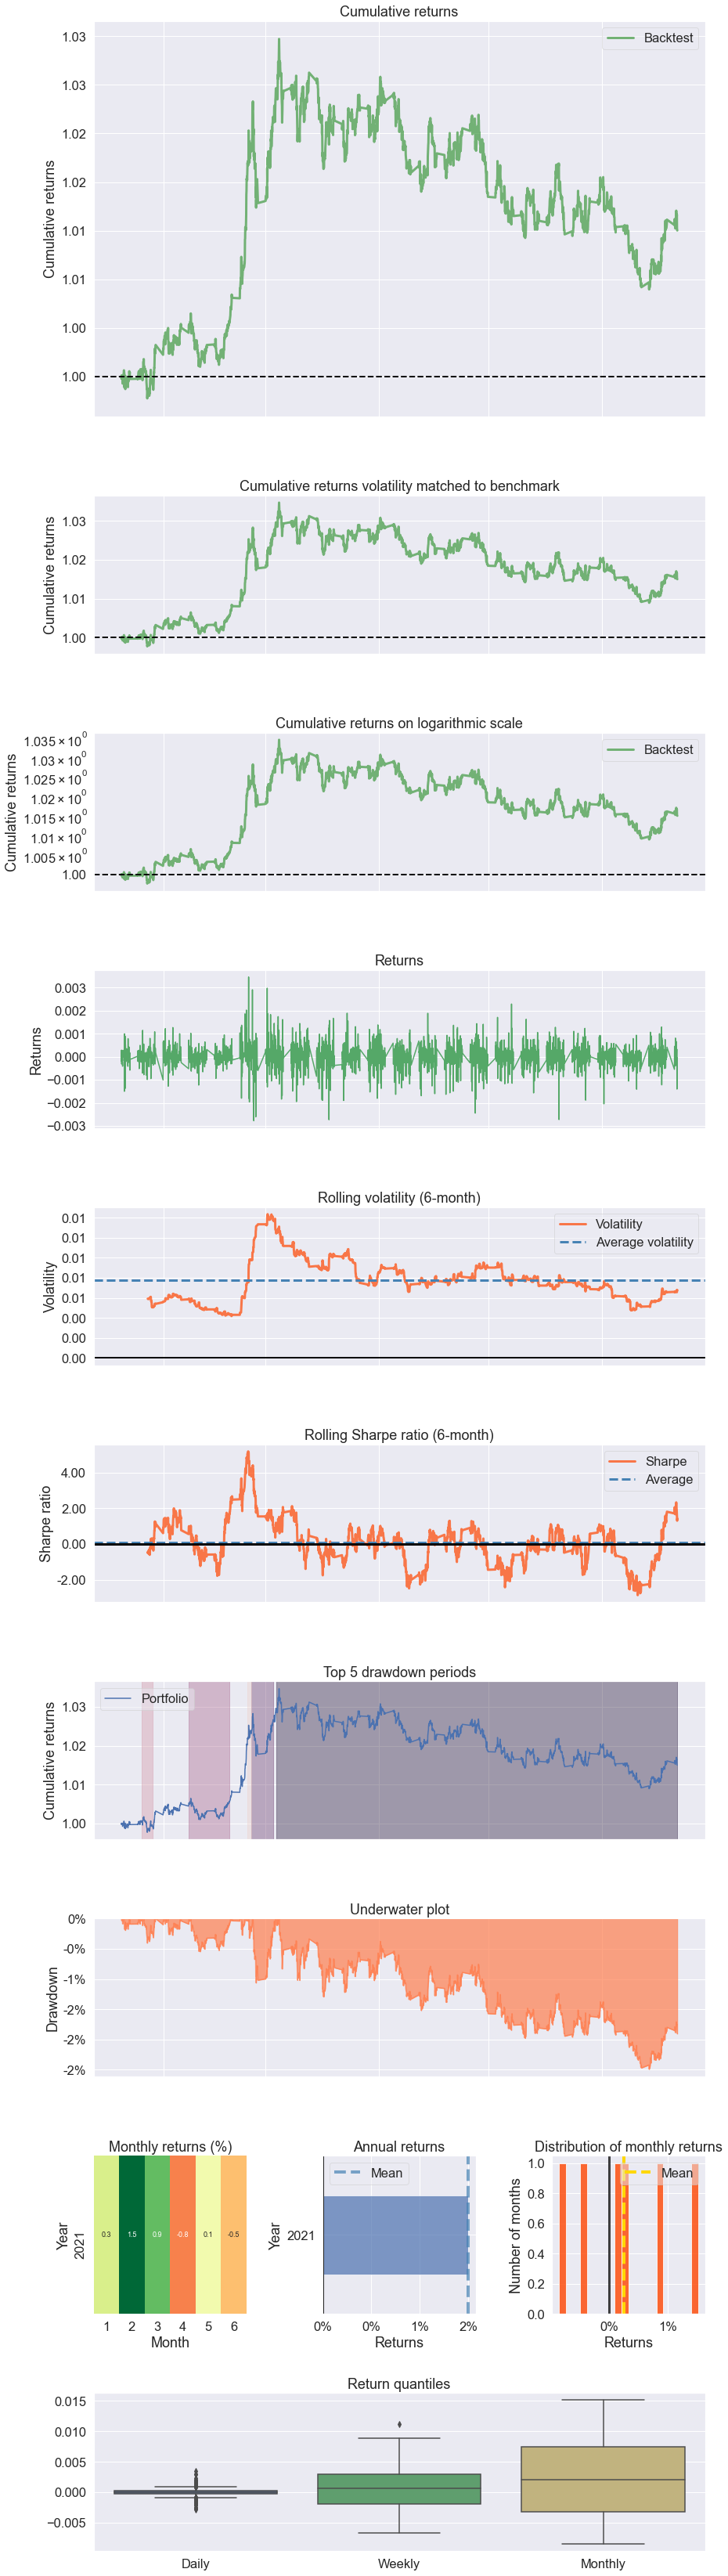

In [18]:
# %%script false --no-raise-error

import pandas as pd
import pyfolio as pf
import quantstats as qs

# Silence pyfolio warnings
import warnings
warnings.filterwarnings('ignore')

###### ДАННЫЕ ИЗ ФАЙЛА

base_path = "~/projects/life/trrrading/data"
path = f"{base_path}/forex/live-EUR:CHF.E.FX-quotes-60-small-1.jsonl"

md = pd.read_json(path, orient='records', lines=True)
md = md.rename(columns={
    "timestamp": "Date", "open": 'Open', 'high': 'High',
    "low": "Low", "close": "Close"
})
md.set_index('Date', inplace=True)
md.sort_index(inplace=True)

ohlc_dict = {'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'}
md = md.resample('1h').apply(ohlc_dict)
md.dropna(inplace=True)

rets = md[['Close']].pct_change().dropna()
rets.index = rets.index.tz_localize("UTC")


# ####### ДАННЫЕ ИЗ pandas_datareader
#
# from pandas_datareader import data as web
# ret = web.get_data_yahoo("FB")
# ret.reset_index(level=0, inplace=True)
# ret.set_index('Date', drop=False, inplace=True)
# rets = ret[['Adj Close']].pct_change().dropna()
# rets.columns = ["Close"]
# rets.index = rets.index.tz_localize("UTC")


# ###### Данные из Yahoo через quantstats
# #
# rets = qs.utils.download_returns('FB')
# rets = rets.to_frame().dropna()
# rets.index = rets.index.tz_localize("UTC")

# print(type(rets.index[0]))
# print(type(rets.head(10)["Close"]))

pf.create_returns_tear_sheet(rets["Close"])
